In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, RocCurveDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from tqdm import trange

**Load Data**

In [2]:
# Load anti-cancer peptide (ACP) data
df = pd.read_csv("anticancer_peptides.csv")

# Create a tokenizer to convert sequences to token indices
tokens = list(set(df["sequence"].sum()))
n_tokens = len(tokens)
pad_token = n_tokens
tokenizer = LabelEncoder()
tokenizer.fit(tokens)

# Apply tokenizer
token_indices = []
for sequence in df["sequence"]:
    token_indices.append(tokenizer.transform(list(sequence)))

# Pad token indices to the same length
X = nn.utils.rnn.pad_sequence(
    [torch.tensor(tokens, dtype=torch.long) for tokens in token_indices],
    batch_first=True,
    padding_value=pad_token,
)

# Target
y = torch.tensor(df["target"].values, dtype=torch.float32)
y.mean()

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

# Create DataLoaders
batch_size = 256
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

**model**

In [3]:
# Define RNN model
class ACP_RNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=32, hidden_dim=64, num_layers=1, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size + 1, embed_dim, padding_idx=pad_token)

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        embedded = self.embedding(x)          # (B, L, E)
        outputs, _ = self.lstm(embedded)      # (B, L, H)
        pooled = outputs.mean(dim=1)          # (B, H)
        logits = self.fc(pooled)              # (B, 1)
        return torch.sigmoid(logits)

model = ACP_RNN(vocab_size=n_tokens)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

**Train**

Epoch 1: train=0.6731, test=0.6693
Epoch 2: train=0.6660, test=0.6626
Epoch 3: train=0.6593, test=0.6555
Epoch 4: train=0.6507, test=0.6472
Epoch 5: train=0.6457, test=0.6368
Epoch 6: train=0.6324, test=0.6239
Epoch 7: train=0.6176, test=0.6052
Epoch 8: train=0.6008, test=0.5919
Epoch 9: train=0.5893, test=0.5756
Epoch 10: train=0.5713, test=0.5475
Epoch 11: train=0.5431, test=0.5269
Epoch 12: train=0.5280, test=0.5158
Epoch 13: train=0.5167, test=0.5053
Epoch 14: train=0.5059, test=0.4981
Epoch 15: train=0.5057, test=0.5012
Epoch 16: train=0.4996, test=0.4906
Epoch 17: train=0.4964, test=0.4859
Epoch 18: train=0.4848, test=0.4815
Epoch 19: train=0.4855, test=0.4814
Epoch 20: train=0.4786, test=0.4777


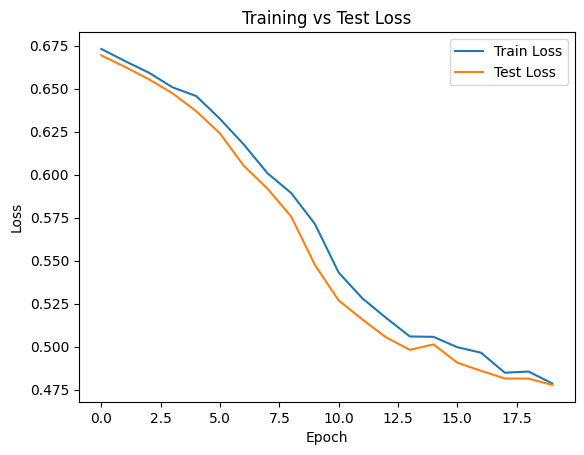

In [4]:
# Train the model
def train_model(model, train_loader, test_loader, epochs=20, patience=3):
    best_loss = float("inf")
    patience_counter = 0

    train_losses = []
    test_losses = []

    for epoch in range(epochs):
        model.train()
        train_loss = 0

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            preds = model(X_batch).squeeze()
            loss = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_losses.append(train_loss / len(train_loader))

        # Validation
        model.eval()
        test_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                preds = model(X_batch).squeeze()
                loss = criterion(preds, y_batch)
                test_loss += loss.item()

        test_losses.append(test_loss / len(test_loader))

        print(f"Epoch {epoch+1}: train={train_losses[-1]:.4f}, test={test_losses[-1]:.4f}")

        # Early stopping
        if test_losses[-1] < best_loss:
            best_loss = test_losses[-1]
            patience_counter = 0
            torch.save(model.state_dict(), "best_model.pt")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    model.load_state_dict(torch.load("best_model.pt"))
    return train_losses, test_losses

train_losses, test_losses = train_model(model, train_loader, test_loader)

# Plot training and test losses
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Test Loss")
plt.legend()
plt.show()

**Evaluate**

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy:  0.691
Precision: 0.000
Recall:    0.000
AUC:       0.847


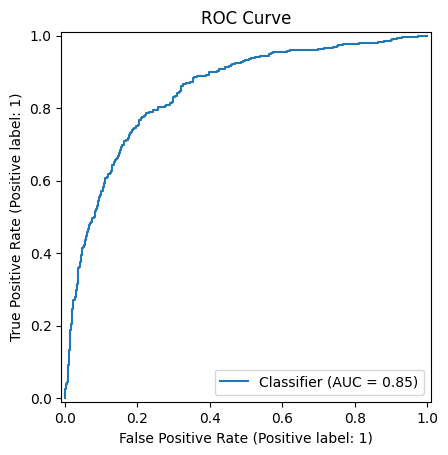

In [5]:
# Evaluate the model using accuracy, precision, recall, and AUC
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        preds = model(X_batch).squeeze()
        all_preds.extend(preds.numpy())
        all_labels.extend(y_batch.numpy())

binary_preds = (np.array(all_preds) >= 0.5).astype(int)

accuracy = accuracy_score(all_labels, binary_preds)
precision = precision_score(all_labels, binary_preds)
recall = recall_score(all_labels, binary_preds)
auc = roc_auc_score(all_labels, all_preds)

print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"AUC:       {auc:.3f}")

# ROC Curve
RocCurveDisplay.from_predictions(all_labels, all_preds)
plt.title("ROC Curve")
plt.show()